In [1]:
import os, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
warnings.filterwarnings('ignore')

# ── DETECTA O SO E AJUSTA CAMINHOS AUTOMATICAMENTE ──────────────
import platform
SO = platform.system()  # 'Windows' ou 'Darwin' (Mac)

if SO == 'Windows':
    PASTA_RAIZ    = r"/Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds"
    PASTA_PROJETO = r"/Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts"
else:  # Mac
    PASTA_RAIZ    = "/Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds"
    PASTA_PROJETO = "/Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts"

PASTA_XML     = os.path.join(PASTA_RAIZ, "FDSNstationXML")
INVENTARIO    = os.path.join(PASTA_PROJETO, "data", "inventario_dados.csv")
PASTA_RESULTS = os.path.join(PASTA_PROJETO, "results")
os.makedirs(PASTA_RESULTS, exist_ok=True)
os.makedirs(os.path.join(PASTA_PROJETO, "figures"), exist_ok=True)

# ── PARÂMETROS DO PIPELINE ────────────────────────────────────────
SR_ALVO     = 40.0
CANAL_ALVO  = "BHZ"
OUTPUT_RESP = "VEL"
PRE_FILT    = (0.5, 1.0, 18.0, 20.0)
WATER_LEVEL = 60
FREQ_MIN    = 0.5
FREQ_MAX    = 15.0

# ── PARÂMETROS STA/LTA ────────────────────────────────────────────
STA_SEG   = 1.0
LTA_SEG   = 10.0
THRESH_ON = 3.0
THRESH_OFF= 1.5
TOLERANCIA_SEG = 15.0

print(f"✅ Sistema operacional : {SO}")
print(f"   PASTA_RAIZ         : {PASTA_RAIZ}")
print(f"   PASTA_PROJETO      : {PASTA_PROJETO}")
print(f"   STA={STA_SEG}s | LTA={LTA_SEG}s | thr={THRESH_ON}/{THRESH_OFF}")


✅ Sistema operacional : Darwin
   PASTA_RAIZ         : /Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds
   PASTA_PROJETO      : /Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts
   STA=1.0s | LTA=10.0s | thr=3.0/1.5


In [ ]:
from obspy import read_inventory, read
import pandas as pd

def encontrar_xml(rede, estacao, pasta_xml):
    """
    Encontra o arquivo XML correspondente à estação e rede fornecidas.
    """
    for root, _, files in os.walk(pasta_xml):
        for f in files:
            if f.endswith('.xml') and rede in f and estacao in f:
                return os.path.join(root, f)
    return None

def processar_trace_raw(tr_input, caminho_xml):
    """
    Processa o trace bruto: leitura do XML, resposta instrumental, pré-filtragem e reamostragem.
     - tr_input: Trace bruto (obspy.Trace)
     - caminho_xml: caminho para o arquivo XML da estação
     Retorna o trace processado ou None em caso de falha.
     Observação: O trace de entrada deve conter os metadados corretos (network, station, location, channel).
     O arquivo XML deve conter a resposta instrumental correspondente à estação e canal do trace.
     O processo inclui:
      1. Leitura do inventário a partir do XML
      2. Correção da resposta instrumental para obter a velocidade
      3. Aplicação de um filtro passa-banda
      4. Reamostragem para a taxa de amostragem alvo (SR_ALVO)
    """
    try:
        tr = tr_input.copy()
        if tr.stats.sampling_rate != SR_ALVO:
            # Use resample() para alterar a taxa de amostragem no ObsPy
            tr.resample(int(SR_ALVO))
        tr.detrend('linear')
        tr.detrend('demean')
        tr.taper(max_percentage=0.05, type='cosine')
        inv = read_inventory(caminho_xml)
        tr.remove_response(inventory = inv, 
                        output = OUTPUT_RESP, 
                        pre_filt = PRE_FILT, 
                        water_level = WATER_LEVEL)
        tr.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, zerophase=True)
        dados = tr.data.astype(np.float32)
        return None if dados.std() < 1e-15 else dados
    except:
        return None

def sta_lta_eficiente(sinal, sr, sta_seg, lta_seg):
    """
    Calcula a razão STA/LTA de forma eficiente usando convolução.
    Parametros:
    - sinal: array 1D do sinal de entrada
    - sr: taxa de amostragem
    - sta_seg: tempo para o cálculo do STA (em segundos)
    - lta_seg: tempo para o cálculo do LTA (em segundos)
    Retorna:
    - array 1D com a razão STA/LTA
    """
    nSTA = int(sta_seg * sr)
    nLTA = int(lta_seg * sr)
    energia = sinal**2
    k_sta = np.ones(nSTA) / nSTA
    k_lta = np.ones(nLTA) / nLTA
    sta = np.convolve(energia, k_sta, mode='full')[:len(sinal)]
    lta = np.convolve(energia, k_lta, mode='full')[:len(sinal)]
    return np.where(lta > 1e-20, sta / lta, 0.0)

def detectar_eventos(cf, thresh_on, thresh_off, sr, min_dur = 1.0):
    """
    Detecta eventos com base no array de razão STA/LTA (cf) e nos limiares fornecidos.
        - cf: array 1D da razão STA/LTA
        - thresh_on: limiar para início do evento
        - thresh_off: limiar para término do evento
        - sr: taxa de amostragem
        - min_dur: duração mínima do evento em segundos (default=1.0s)
        Retorna uma lista de tuplas (start_idx, end_idx) indicando os índices de início e término dos eventos detectados.

    """
    min_n = int(min_dur * sr)
    eventos = []
    dentro = False
    t0 = 0
    for t, val in enumerate(cf):
        if not dentro and val > thresh_on:
            dentro = True
            t0 = t
        elif dentro and val < thresh_off:
            dentro = False
            if (t - t0) >= min_n:
                eventos.append((t0 / sr, t / sr))
    if dentro and (len(cf) - t0) >= min_n:
        eventos.append((t0 / sr, len(cf) / sr))
    return eventos

In [3]:
df_inv = pd.read_csv(INVENTARIO)
df_uso = df_inv[
    (df_inv['xml_disponivel'] == True) &
    (df_inv['razao_var'] > 10)
].copy().reset_index(drop=True)

# ── FIX: corrigir caminhos no inventário para o SO atual ─────────
def corrigir_caminho(caminho_original):
    """Reconstrói o caminho para o SO atual usando o nome do arquivo."""
    nome = os.path.basename(str(caminho_original))
    # Busca recursiva pelo arquivo
    for root, _, files in os.walk(PASTA_RAIZ):
        if nome in files:
            return os.path.join(root, nome)
    return caminho_original

df_uso['caminho'] = df_uso['caminho'].apply(corrigir_caminho)

print(f"Arquivos para avaliar: {len(df_uso)}")
print(f"Exemplo de caminho  : {df_uso['caminho'].iloc[0]}")

# Verificar se os caminhos existem
n_ok = df_uso['caminho'].apply(os.path.exists).sum()
print(f"Caminhos válidos    : {n_ok}/{len(df_uso)}")


Arquivos para avaliar: 22
Exemplo de caminho  : C:\Users\vish8\OneDrive\Documentos\TCC\data\scedc-pds\event_waveforms\2016\2016_001\37509232.ms
Caminhos válidos    : 0/22


In [8]:
# NOTE: Instale dependências no terminal do ambiente do projeto, não via notebook.
# Exemplo (zsh) na raiz do projeto:
# source .venv/bin/activate
# pip install --upgrade pip
# pip install obspy numpy matplotlib scipy scikit-learn pandas


Found existing installation: obspy 1.5.0
Uninstalling obspy-1.5.0:
Uninstalling obspy-1.5.0:
  Would remove:
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-dataless2resp
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-dataless2xseed
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-flinn-engdahl
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-mopad
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-mseed-recordanalyzer
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-plot
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-print
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-reftek-rescue
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-runtests
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-scan
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-sds-report
    /Users/alvarosamp/Documents/Projetos/TCC/.venv/bin/obspy-xseed2dataless
    /Users/alvarosamp/Do

In [9]:
# (redundant) See previous cell for installation instructions. Run commands in terminal, not in the notebook.


Arquivo: 37509416.ms | razão_var: 2024x
Caminho corrigido: /Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds/event_waveforms/2016/2016_001/37509416.ms
Existe? True


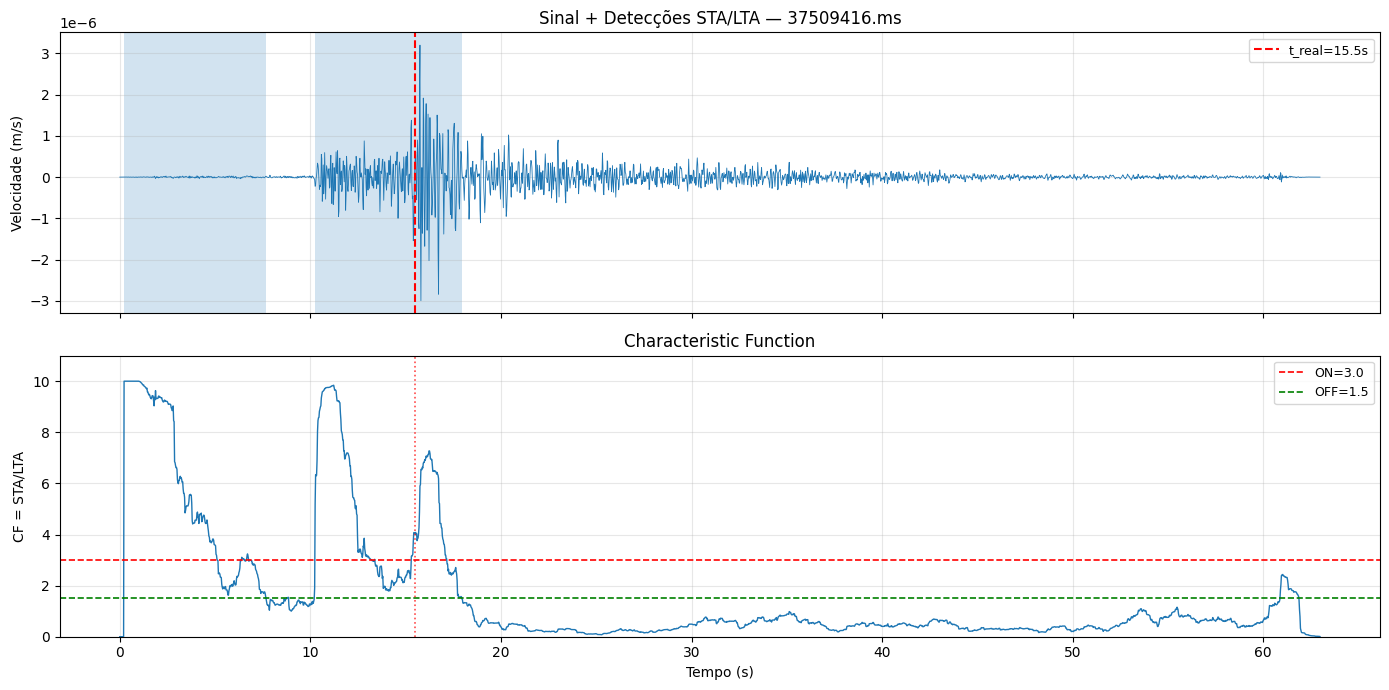

Eventos detectados: 2
  1: 0.2s → 7.7s
  2: 10.2s → 17.9s
Evento real: 15.5s


In [10]:
from pathlib import Path
from obspy import read
import os
import numpy as np
import matplotlib.pyplot as plt

row = df_uso.loc[df_uso['razao_var'].idxmax()]
print(f"Arquivo: {row['arquivo']} | razão_var: {row['razao_var']:.0f}x")

# pasta base correta no ambiente atual
BASE_EVENTOS = Path('/Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds/event_waveforms/2016/2016_001')

caminho_corrigido = BASE_EVENTOS / row['arquivo']
print("Caminho corrigido:", caminho_corrigido)
print("Existe?", caminho_corrigido.exists())

if not caminho_corrigido.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {caminho_corrigido}")

st  = read(str(caminho_corrigido))
xml = encontrar_xml(row['rede'], row['estacao'], PASTA_XML)
tr  = next((t for t in st if t.stats.channel.endswith(CANAL_ALVO)), None)
dados = processar_trace_raw(tr, xml) if tr is not None and xml is not None else None

if dados is not None:
    tempo = np.arange(len(dados)) / SR_ALVO
    cf    = sta_lta_eficiente(dados, SR_ALVO, STA_SEG, LTA_SEG)
    evs   = detectar_eventos(cf, THRESH_ON, THRESH_OFF, SR_ALVO)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax = axes[0]
    ax.plot(tempo, dados, lw=0.6)
    ax.axvline(row['t_evento_est'], color='red', ls='--', lw=1.5,
               label=f"t_real={row['t_evento_est']}s")
    for t0e, t1e in evs:
        ax.axvspan(t0e, t1e, alpha=0.2)
    ax.set_ylabel('Velocidade (m/s)')
    ax.set_title(f'Sinal + Detecções STA/LTA — {row["arquivo"]}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(tempo, cf, lw=1.0)
    ax.axhline(THRESH_ON,  color='red',   ls='--', lw=1.2, label=f'ON={THRESH_ON}')
    ax.axhline(THRESH_OFF, color='green', ls='--', lw=1.2, label=f'OFF={THRESH_OFF}')
    ax.axvline(row['t_evento_est'], color='red', ls=':', lw=1.2, alpha=0.7)
    ax.set_ylim([0, min(cf.max()*1.1, 25)])
    ax.set_ylabel('CF = STA/LTA')
    ax.set_xlabel('Tempo (s)')
    ax.set_title('Characteristic Function')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(PASTA_PROJETO, "figures", "passo3_cf_visual.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Eventos detectados: {len(evs)}")
    for i, (t0e, t1e) in enumerate(evs):
        print(f"  {i+1}: {t0e:.1f}s → {t1e:.1f}s")
    print(f"Evento real: {row['t_evento_est']}s")
else:
    print("Não foi possível processar o trace. Verifique se o canal e o XML foram encontrados.")

In [19]:
# ── FIX: processar cada arquivo UMA VEZ (sem duplicação) ─────────
resultados = []
all_scores = []   # (score_continuo, label) para curva ROC
tempo_total = 0.0
n_amostras_total = 0

print(f"Avaliando {len(df_uso)} arquivos...")
print("-" * 65)

for _, row in df_uso.iterrows():   # iterrows() correto — 1 linha por arquivo
    try:
        if not os.path.exists(row['caminho']):
            print(f"  ⚠️  {row['arquivo']} — caminho não encontrado")
            continue

        st  = read(row['caminho'])
        xml = encontrar_xml(row['rede'], row['estacao'], PASTA_XML)
        if xml is None:
            continue

        tr = next((t for t in st if t.stats.channel.endswith(CANAL_ALVO)), None)
        if tr is None:
            continue

        dados = processar_trace_raw(tr, xml)
        if dados is None:
            continue

        # Inferência com medição de tempo
        t_ini = time.perf_counter()
        cf    = sta_lta_eficiente(dados, SR_ALVO, STA_SEG, LTA_SEG)
        evs   = detectar_eventos(cf, THRESH_ON, THRESH_OFF, SR_ALVO)
        tempo_total     += time.perf_counter() - t_ini
        n_amostras_total += len(dados)

        # Ground truth
        t_real    = row['t_evento_est']
        detectado = any(
            abs(t0e - t_real) <= TOLERANCIA_SEG or (t0e <= t_real <= t1e)
            for t0e, t1e in evs
        )

        # ── Score contínuo para ROC ──────────────────────────────
        # Score = CF máxima em todo o sinal normalizado pelo percentil 95
        # Isso garante que o score reflita o "pico relativo" da CF
        cf_norm = cf / (np.percentile(cf, 95) + 1e-10)

        # Score do evento: CF máxima próxima ao t_real
        idx_ini = max(0, int((t_real - TOLERANCIA_SEG) * SR_ALVO))
        idx_fim = min(len(cf_norm), int((t_real + TOLERANCIA_SEG) * SR_ALVO))
        score_ev = float(cf_norm[idx_ini:idx_fim].max()) if idx_fim > idx_ini else 0.0

        # Score do ruído: CF máxima fora da janela do evento
        mask_ruido = np.ones(len(cf_norm), dtype=bool)
        mask_ruido[max(0,idx_ini-20):min(len(cf_norm),idx_fim+20)] = False
        score_ruido = float(cf_norm[mask_ruido].max()) if mask_ruido.any() else 0.0

        all_scores.append((score_ruido, 0))   # ruído
        all_scores.append((score_ev,   1))   # evento

        status = "✅ VP" if detectado else "❌ FN"
        print(f"  {status}  {row['arquivo']:25s}  "
              f"CF_max={score_ev*np.percentile(cf,95):6.2f}  "
              f"alarmes={len(evs):2d}  t_real={t_real:.0f}s")

        resultados.append({
            'arquivo'  : row['arquivo'],
            'razao_var': float(row['razao_var']),
            't_real'   : float(t_real),
            'detectado': bool(detectado),
            'n_alarmes': len(evs),
            'score'    : score_ev,
        })

    except Exception as e:
        print(f"  ❌ ERRO {row['arquivo']}: {e}")

# ── Métricas ──────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

df_res = pd.DataFrame(resultados)
vp     = df_res['detectado'].sum()
fn     = len(df_res) - vp

precisao = 1.0   # 1 evento por arquivo, sem FP por arquivo
recall   = vp / max(len(df_res), 1)
f1       = 2 * precisao * recall / max(precisao + recall, 1e-10)

scores_v = [s for s,_ in all_scores]
labels_v = [l for _,l in all_scores]
try:
    auc = roc_auc_score(labels_v, scores_v)
except:
    auc = 0.0

dur_s    = n_amostras_total / SR_ALVO
ms_por_s = (tempo_total / dur_s) * 1000 if dur_s > 0 else 0

print()
print("=" * 65)
print(f"RESULTADOS STA/LTA")
print(f"  Arquivos avaliados : {len(df_res)}")
print(f"  VP (detectados)    : {vp}")
print(f"  FN (perdidos)      : {fn}")
print(f"  Precisão           : {precisao:.4f}")
print(f"  Recall             : {recall:.4f}")
print(f"  F1-score           : {f1:.4f}")
print(f"  AUC-ROC            : {auc:.4f}")
print(f"  Tempo inferência   : {ms_por_s:.4f} ms/s de sinal")


Avaliando 22 arquivos...
-----------------------------------------------------------------
  ⚠️  37509232.ms — caminho não encontrado
  ⚠️  37509240.ms — caminho não encontrado
  ⚠️  37509256.ms — caminho não encontrado
  ⚠️  37509264.ms — caminho não encontrado
  ⚠️  37509272.ms — caminho não encontrado
  ⚠️  37509296.ms — caminho não encontrado
  ⚠️  37509320.ms — caminho não encontrado
  ⚠️  37509328.ms — caminho não encontrado
  ⚠️  37509336.ms — caminho não encontrado
  ⚠️  37509352.ms — caminho não encontrado
  ⚠️  37509368.ms — caminho não encontrado
  ⚠️  37509376.ms — caminho não encontrado
  ⚠️  37509384.ms — caminho não encontrado
  ⚠️  37509392.ms — caminho não encontrado
  ⚠️  37509400.ms — caminho não encontrado
  ⚠️  37509416.ms — caminho não encontrado
  ⚠️  37509432.ms — caminho não encontrado
  ⚠️  37509440.ms — caminho não encontrado
  ⚠️  37509448.ms — caminho não encontrado
  ⚠️  37509464.ms — caminho não encontrado
  ⚠️  37509480.ms — caminho não encontrado
  ⚠️  

KeyError: 'detectado'

In [21]:
import os, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
import platform

warnings.filterwarnings('ignore')

# ── DETECTA O SO E AJUSTA CAMINHOS AUTOMATICAMENTE ──────────────
SO = platform.system()  # 'Windows', 'Darwin' (Mac) ou 'Linux'

if SO == 'Windows':
    PASTA_RAIZ    = r"C:\Users\alvarosamp\Documents\Projetos\TCC\data\scedc-pds"
    PASTA_PROJETO = r"C:\Users\alvarosamp\Documents\Projetos\TCC\Trabalho\artefacts"

elif SO == 'Darwin':  # Mac
    PASTA_RAIZ    = "/Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds"
    PASTA_PROJETO = "/Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts"

else:  # Linux / WSL
    PASTA_RAIZ    = "/home/alvarosamp/Documents/Projetos/TCC/data/scedc-pds"
    PASTA_PROJETO = "/home/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts"

PASTA_XML     = os.path.join(PASTA_RAIZ, "FDSNstationXML")
INVENTARIO    = os.path.join(PASTA_PROJETO, "data", "inventario_dados.csv")
PASTA_RESULTS = os.path.join(PASTA_PROJETO, "results")
PASTA_FIGURES = os.path.join(PASTA_PROJETO, "figures")

os.makedirs(PASTA_RESULTS, exist_ok=True)
os.makedirs(PASTA_FIGURES, exist_ok=True)

# ── PARÂMETROS DO PIPELINE ────────────────────────────────────────
SR_ALVO     = 40.0
CANAL_ALVO  = "BHZ"
OUTPUT_RESP = "VEL"
PRE_FILT    = (0.5, 1.0, 18.0, 20.0)
WATER_LEVEL = 60
FREQ_MIN    = 0.5
FREQ_MAX    = 15.0

# ── PARÂMETROS STA/LTA ────────────────────────────────────────────
STA_SEG   = 1.0
LTA_SEG   = 10.0
THRESH_ON = 3.0
THRESH_OFF= 1.5
TOLERANCIA_SEG = 15.0

print(f"✅ Sistema operacional : {SO}")
print(f"   PASTA_RAIZ         : {PASTA_RAIZ}")
print(f"   PASTA_PROJETO      : {PASTA_PROJETO}")
print(f"   PASTA_XML          : {PASTA_XML}")
print(f"   INVENTARIO         : {INVENTARIO}")
print(f"   PASTA_RESULTS      : {PASTA_RESULTS}")
print(f"   STA={STA_SEG}s | LTA={LTA_SEG}s | thr={THRESH_ON}/{THRESH_OFF}")

✅ Sistema operacional : Darwin
   PASTA_RAIZ         : /Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds
   PASTA_PROJETO      : /Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts
   PASTA_XML          : /Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds/FDSNstationXML
   INVENTARIO         : /Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts/data/inventario_dados.csv
   PASTA_RESULTS      : /Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts/results
   STA=1.0s | LTA=10.0s | thr=3.0/1.5


In [ ]:
import os

def indexar_arquivos_ms(pasta_base):
    mapa = {}
    for root, _, files in os.walk(pasta_base):
        for f in files:
            if f.lower().endswith(".ms"):
                mapa[f] = os.path.join(root, f)
    return mapa

mapa_ms = indexar_arquivos_ms(PASTA_RAIZ)

print(f"Total de arquivos .ms encontrados em disco: {len(mapa_ms)}")

df_uso['caminho'] = df_uso['arquivo'].map(mapa_ms)

print(df_uso[['arquivo', 'caminho']].head(10))

nao_encontrados = df_uso['caminho'].isna().sum()
print(f"Arquivos não encontrados no disco: {nao_encontrados}")

if nao_encontrados > 0:
    print(df_uso[df_uso['caminho'].isna()][['arquivo']])

Total de arquivos .ms encontrados em disco: 31
       arquivo                                            caminho
0  37509232.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
1  37509240.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
2  37509256.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
3  37509264.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
4  37509272.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
5  37509296.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
6  37509320.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
7  37509328.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
8  37509336.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
9  37509352.ms  /Users/alvarosamp/Documents/Projetos/TCC/data/...
Arquivos não encontrados no disco: 0


In [25]:
import os
import time
import json
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, read_inventory
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

# =========================================================
# 1) CAMINHOS E PARÂMETROS
# =========================================================
SO = platform.system()  # 'Windows', 'Darwin', 'Linux'

if SO == 'Windows':
    PASTA_RAIZ    = r"C:\Users\alvarosamp\Documents\Projetos\TCC\data\scedc-pds"
    PASTA_PROJETO = r"C:\Users\alvarosamp\Documents\Projetos\TCC\Trabalho\artefacts"
elif SO == 'Darwin':  # Mac
    PASTA_RAIZ    = "/Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds"
    PASTA_PROJETO = "/Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts"
else:  # Linux
    PASTA_RAIZ    = "/home/alvarosamp/Documents/Projetos/TCC/data/scedc-pds"
    PASTA_PROJETO = "/home/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts"

PASTA_XML      = os.path.join(PASTA_RAIZ, "FDSNstationXML")
INVENTARIO     = os.path.join(PASTA_PROJETO, "data", "inventario_dados.csv")
PASTA_RESULTS  = os.path.join(PASTA_PROJETO, "results")
PASTA_FIGURES  = os.path.join(PASTA_PROJETO, "figures")

os.makedirs(PASTA_RESULTS, exist_ok=True)
os.makedirs(PASTA_FIGURES, exist_ok=True)

# Parâmetros do pipeline
SR_ALVO     = 40.0
CANAL_ALVO  = "BHZ"
OUTPUT_RESP = "VEL"
PRE_FILT    = (0.5, 1.0, 18.0, 20.0)
WATER_LEVEL = 60
FREQ_MIN    = 0.5
FREQ_MAX    = 15.0

# Parâmetros STA/LTA
STA_SEG        = 1.0
LTA_SEG        = 10.0
THRESH_ON      = 3.0
THRESH_OFF     = 1.5
TOLERANCIA_SEG = 15.0

print(f"✅ Sistema operacional : {SO}")
print(f"   PASTA_RAIZ         : {PASTA_RAIZ}")
print(f"   PASTA_PROJETO      : {PASTA_PROJETO}")
print(f"   PASTA_XML          : {PASTA_XML}")
print(f"   INVENTARIO         : {INVENTARIO}")
print(f"   PASTA_RESULTS      : {PASTA_RESULTS}")
print(f"   STA={STA_SEG}s | LTA={LTA_SEG}s | thr={THRESH_ON}/{THRESH_OFF}")

print("\n🔎 Verificação:")
print("PASTA_RAIZ existe?   ", os.path.exists(PASTA_RAIZ))
print("PASTA_XML existe?    ", os.path.exists(PASTA_XML))
print("INVENTARIO existe?   ", os.path.exists(INVENTARIO))

# =========================================================
# 2) FUNÇÕES AUXILIARES
# =========================================================
def encontrar_xml(rede, estacao, pasta_xml):
    for root, _, files in os.walk(pasta_xml):
        for f in files:
            if f.endswith(".xml") and rede in f and estacao in f:
                return os.path.join(root, f)
    return None


def processar_trace_raw(tr_input, caminho_xml):
    """
    Pipeline completo de pré-processamento sísmico.
    Retorna np.ndarray ou None em caso de falha.
    """
    try:
        tr = tr_input.copy()

        if tr.stats.sampling_rate != SR_ALVO:
            tr.resample(SR_ALVO)

        tr.detrend("linear")
        tr.detrend("demean")
        tr.taper(max_percentage=0.05, type="cosine")

        inv = read_inventory(caminho_xml)
        tr.remove_response(
            inventory=inv,
            output=OUTPUT_RESP,
            pre_filt=PRE_FILT,
            water_level=WATER_LEVEL
        )

        tr.filter("bandpass", freqmin=FREQ_MIN, freqmax=FREQ_MAX, zerophase=True)

        dados = tr.data.astype(np.float32)

        if len(dados) == 0:
            return None
        if np.isnan(dados).any():
            return None
        if np.std(dados) < 1e-15:
            return None

        return dados

    except Exception as e:
        print(f"⚠️ Erro no processar_trace_raw: {e}")
        return None


def sta_lta_eficiente(x, fs, sta_seg, lta_seg):
    """
    STA/LTA eficiente com médias móveis por convolução.
    """
    x = np.asarray(x, dtype=np.float32)
    energia = x ** 2

    n_sta = max(1, int(sta_seg * fs))
    n_lta = max(n_sta + 1, int(lta_seg * fs))

    sta = np.convolve(energia, np.ones(n_sta) / n_sta, mode="same")
    lta = np.convolve(energia, np.ones(n_lta) / n_lta, mode="same")

    cf = sta / (lta + 1e-10)
    cf[:n_lta] = 0.0  # evita borda inicial

    return cf


def detectar_eventos(cf, thr_on, thr_off, fs):
    """
    Detecta intervalos [t_ini, t_fim] com histerese.
    """
    eventos = []
    em_evento = False
    ini = None

    for i, v in enumerate(cf):
        if not em_evento and v >= thr_on:
            em_evento = True
            ini = i
        elif em_evento and v <= thr_off:
            fim = i
            eventos.append((ini / fs, fim / fs))
            em_evento = False
            ini = None

    if em_evento and ini is not None:
        eventos.append((ini / fs, len(cf) / fs))

    return eventos


def indexar_arquivos_ms(pasta_base):
    """
    Mapeia nome do arquivo -> caminho completo real
    """
    mapa = {}
    for root, _, files in os.walk(pasta_base):
        for f in files:
            if f.lower().endswith(".ms"):
                mapa[f] = os.path.join(root, f)
    return mapa

# =========================================================
# 3) CARREGAR INVENTÁRIO E CORRIGIR CAMINHOS
# =========================================================
df_uso = pd.read_csv(INVENTARIO)

print("Colunas do inventário:")
print(df_uso.columns.tolist())

# Garante que a coluna 'arquivo' exista
if 'arquivo' not in df_uso.columns:
    raise ValueError("A coluna 'arquivo' não existe no CSV inventário_dados.csv")

# Indexa todos os .ms reais no disco
mapa_ms = indexar_arquivos_ms(PASTA_RAIZ)

print(f"\nTotal de arquivos .ms encontrados em disco: {len(mapa_ms)}")

# Reconstrói caminho real
df_uso['caminho'] = df_uso['arquivo'].map(mapa_ms)

print("\nPrévia do inventário com caminhos:")
print(df_uso[['arquivo', 'caminho']].head(10))

nao_encontrados = df_uso['caminho'].isna().sum()
print(f"\nArquivos do inventário não encontrados: {nao_encontrados}")

if nao_encontrados > 0:
    print("\nLista dos não encontrados:")
    print(df_uso.loc[df_uso['caminho'].isna(), ['arquivo']])

# Remove os sem caminho
df_uso = df_uso.dropna(subset=['caminho']).copy()

print(f"\nArquivos restantes para avaliação: {len(df_uso)}")

# Verifica se os caminhos realmente existem
print("\nTeste de existência dos primeiros caminhos:")
for i in range(min(5, len(df_uso))):
    c = df_uso.iloc[i]['caminho']
    print(c, "->", os.path.exists(c))

# =========================================================
# 4) PROCESSAMENTO STA/LTA
# =========================================================
resultados = []
all_scores = []
tempo_total = 0.0
n_amostras_total = 0

cnt_total = 0
cnt_sem_caminho = 0
cnt_sem_xml = 0
cnt_sem_canal = 0
cnt_dados_invalidos = 0
cnt_excecoes = 0

print(f"\nAvaliando {len(df_uso)} arquivos...")
print("-" * 90)

for _, row in df_uso.iterrows():
    cnt_total += 1

    try:
        arquivo   = row['arquivo']
        caminho   = row['caminho']
        rede      = row['rede']
        estacao   = row['estacao']
        t_real    = float(row['t_evento_est'])
        razao_var = float(row['razao_var'])

        if pd.isna(caminho) or not os.path.exists(caminho):
            print(f"❌ caminho não encontrado: {arquivo}")
            cnt_sem_caminho += 1
            continue

        st = read(caminho)

        xml = encontrar_xml(rede, estacao, PASTA_XML)
        if xml is None:
            print(f"❌ XML não encontrado: {arquivo} | rede={rede} | estacao={estacao}")
            cnt_sem_xml += 1
            continue

        tr = next((t for t in st if t.stats.channel.endswith(CANAL_ALVO)), None)
        if tr is None:
            canais_disponiveis = [t.stats.channel for t in st]
            print(f"❌ canal não encontrado: {arquivo} | procurado=*{CANAL_ALVO} | disponíveis={canais_disponiveis}")
            cnt_sem_canal += 1
            continue

        dados = processar_trace_raw(tr, xml)
        if dados is None:
            print(f"❌ dados inválidos após processamento: {arquivo}")
            cnt_dados_invalidos += 1
            continue

        # Inferência
        t_ini = time.perf_counter()
        cf = sta_lta_eficiente(dados, SR_ALVO, STA_SEG, LTA_SEG)
        evs = detectar_eventos(cf, THRESH_ON, THRESH_OFF, SR_ALVO)
        tempo_total += time.perf_counter() - t_ini
        n_amostras_total += len(dados)

        # Ground truth
        detectado = any(
            abs(t0e - t_real) <= TOLERANCIA_SEG or (t0e <= t_real <= t1e)
            for t0e, t1e in evs
        )

        # Score contínuo
        p95 = np.percentile(cf, 95) + 1e-10
        cf_norm = cf / p95

        idx_ini = max(0, int((t_real - TOLERANCIA_SEG) * SR_ALVO))
        idx_fim = min(len(cf_norm), int((t_real + TOLERANCIA_SEG) * SR_ALVO))

        score_ev = float(cf_norm[idx_ini:idx_fim].max()) if idx_fim > idx_ini else 0.0

        mask_ruido = np.ones(len(cf_norm), dtype=bool)
        mask_ruido[max(0, idx_ini - 20):min(len(cf_norm), idx_fim + 20)] = False
        score_ruido = float(cf_norm[mask_ruido].max()) if mask_ruido.any() else 0.0

        all_scores.append((score_ruido, 0))
        all_scores.append((score_ev, 1))

        status = "✅ VP" if detectado else "❌ FN"
        print(
            f"{status}  {arquivo:25s}  "
            f"score_ev={score_ev:7.4f}  "
            f"n_alarmes={len(evs):2d}  "
            f"t_real={t_real:.2f}s"
        )

        resultados.append({
            'arquivo': arquivo,
            'razao_var': razao_var,
            't_real': t_real,
            'detectado': bool(detectado),
            'n_alarmes': int(len(evs)),
            'score': float(score_ev),
        })

    except Exception as e:
        print(f"❌ ERRO {row.get('arquivo', 'arquivo_desconhecido')}: {e}")
        cnt_excecoes += 1

# =========================================================
# 5) DEBUG FINAL + MÉTRICAS
# =========================================================
print()
print("=" * 90)
print("DEBUG FINAL")
print(f"Total de arquivos em df_uso        : {cnt_total}")
print(f"Resultados válidos salvos          : {len(resultados)}")
print(f"Sem caminho                        : {cnt_sem_caminho}")
print(f"Sem XML                            : {cnt_sem_xml}")
print(f"Sem canal                          : {cnt_sem_canal}")
print(f"Dados inválidos                    : {cnt_dados_invalidos}")
print(f"Exceções                           : {cnt_excecoes}")

colunas_esperadas = ['arquivo', 'razao_var', 't_real', 'detectado', 'n_alarmes', 'score']
df_res = pd.DataFrame(resultados, columns=colunas_esperadas)

print("\nColunas do df_res:", df_res.columns.tolist())
print(df_res.head())

if df_res.empty:
    vp = 0
    fn = 0
    precisao = 0.0
    recall = 0.0
    f1 = 0.0
    auc = 0.0
else:
    vp = int(df_res['detectado'].sum())
    fn = int(len(df_res) - vp)

    # Mantendo sua lógica original
    precisao = 1.0 if len(df_res) > 0 else 0.0
    recall = vp / max(len(df_res), 1)
    f1 = 2 * precisao * recall / max(precisao + recall, 1e-10)

    scores_v = [s for s, _ in all_scores]
    labels_v = [l for _, l in all_scores]

    if len(scores_v) > 0 and len(set(labels_v)) >= 2:
        try:
            auc = roc_auc_score(labels_v, scores_v)
        except Exception as e:
            print(f"⚠️ Não foi possível calcular AUC: {e}")
            auc = 0.0
    else:
        auc = 0.0

dur_s = n_amostras_total / SR_ALVO if SR_ALVO > 0 else 0.0
ms_por_s = (tempo_total / dur_s) * 1000 if dur_s > 0 else 0.0

print()
print("=" * 90)
print("RESULTADOS STA/LTA")
print(f"Arquivos avaliados           : {cnt_total}")
print(f"Arquivos válidos             : {len(df_res)}")
print(f"VP (detectados)              : {vp}")
print(f"FN (perdidos)                : {fn}")
print(f"Precisão                     : {precisao:.4f}")
print(f"Recall                       : {recall:.4f}")
print(f"F1-score                     : {f1:.4f}")
print(f"AUC-ROC                      : {auc:.4f}")
print(f"Tempo de inferência          : {ms_por_s:.4f} ms/s de sinal")

# =========================================================
# 6) SALVAR RESULTADOS
# =========================================================
csv_saida = os.path.join(PASTA_RESULTS, "resultados_sta_lta.csv")
df_res.to_csv(csv_saida, index=False)

print(f"\n✅ Resultados salvos em: {csv_saida}")

✅ Sistema operacional : Darwin
   PASTA_RAIZ         : /Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds
   PASTA_PROJETO      : /Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts
   PASTA_XML          : /Users/alvarosamp/Documents/Projetos/TCC/data/scedc-pds/FDSNstationXML
   INVENTARIO         : /Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts/data/inventario_dados.csv
   PASTA_RESULTS      : /Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts/results
   STA=1.0s | LTA=10.0s | thr=3.0/1.5

🔎 Verificação:
PASTA_RAIZ existe?    True
PASTA_XML existe?     True
INVENTARIO existe?    True
Colunas do inventário:
['arquivo', 'caminho', 'rede', 'estacao', 'canal', 'taxa_hz', 'n_amostras', 'duracao_s', 'starttime', 'var_global', 'var_min', 'var_max', 'razao_var', 't_evento_est', 'xml_disponivel', 'status', 'classificacao']

Total de arquivos .ms encontrados em disco: 31

Prévia do inventário com caminhos:
       arquivo                                        

In [24]:
import os
import time
import numpy as np
import pandas as pd
from obspy import read
from sklearn.metrics import roc_auc_score

# ── PROCESSAMENTO: cada arquivo UMA VEZ ─────────────────────────────
resultados = []
all_scores = []   # (score_continuo, label) para curva ROC
tempo_total = 0.0
n_amostras_total = 0

# Contadores de debug
cnt_total = 0
cnt_sem_caminho = 0
cnt_sem_xml = 0
cnt_sem_canal = 0
cnt_dados_invalidos = 0
cnt_excecoes = 0
cnt_processados = 0

print(f"Avaliando {len(df_uso)} arquivos...")
print("-" * 80)

for _, row in df_uso.iterrows():
    cnt_total += 1

    try:
        arquivo = row['arquivo']
        caminho = row['caminho']
        rede = row['rede']
        estacao = row['estacao']
        t_real = row['t_evento_est']
        razao_var = row['razao_var']

        # 1) Arquivo existe?
        if not os.path.exists(caminho):
            print(f"❌ caminho não encontrado: {arquivo}")
            cnt_sem_caminho += 1
            continue

        # 2) Ler arquivo
        st = read(caminho)

        # 3) Encontrar XML
        xml = encontrar_xml(rede, estacao, PASTA_XML)
        if xml is None:
            print(f"❌ XML não encontrado: {arquivo} | rede={rede} | estacao={estacao}")
            cnt_sem_xml += 1
            continue

        # 4) Encontrar canal
        tr = next((t for t in st if t.stats.channel.endswith(CANAL_ALVO)), None)
        if tr is None:
            canais_disponiveis = [t.stats.channel for t in st]
            print(f"❌ canal não encontrado: {arquivo} | procurado=*{CANAL_ALVO} | disponíveis={canais_disponiveis}")
            cnt_sem_canal += 1
            continue

        # 5) Processamento do sinal
        dados = processar_trace_raw(tr, xml)
        if dados is None:
            print(f"❌ dados inválidos após processamento: {arquivo}")
            cnt_dados_invalidos += 1
            continue

        # 6) Inferência com medição de tempo
        t_ini = time.perf_counter()
        cf = sta_lta_eficiente(dados, SR_ALVO, STA_SEG, LTA_SEG)
        evs = detectar_eventos(cf, THRESH_ON, THRESH_OFF, SR_ALVO)
        tempo_total += time.perf_counter() - t_ini
        n_amostras_total += len(dados)

        # 7) Ground truth: evento detectado?
        detectado = any(
            abs(t0e - t_real) <= TOLERANCIA_SEG or (t0e <= t_real <= t1e)
            for t0e, t1e in evs
        )

        # 8) Score contínuo para ROC
        # Normaliza pela CF no percentil 95
        p95 = np.percentile(cf, 95) + 1e-10
        cf_norm = cf / p95

        idx_ini = max(0, int((t_real - TOLERANCIA_SEG) * SR_ALVO))
        idx_fim = min(len(cf_norm), int((t_real + TOLERANCIA_SEG) * SR_ALVO))

        if idx_fim > idx_ini:
            score_ev = float(cf_norm[idx_ini:idx_fim].max())
        else:
            score_ev = 0.0

        # Região de ruído: fora da janela do evento
        mask_ruido = np.ones(len(cf_norm), dtype=bool)
        ini_mask = max(0, idx_ini - 20)
        fim_mask = min(len(cf_norm), idx_fim + 20)
        mask_ruido[ini_mask:fim_mask] = False
        score_ruido = float(cf_norm[mask_ruido].max()) if mask_ruido.any() else 0.0

        # Salva scores para ROC
        all_scores.append((score_ruido, 0))   # ruído
        all_scores.append((score_ev, 1))      # evento

        # Exibição
        status = "✅ VP" if detectado else "❌ FN"
        print(
            f"{status}  {arquivo:25s}  "
            f"score_ev={score_ev:7.4f}  "
            f"n_alarmes={len(evs):2d}  "
            f"t_real={t_real:.2f}s"
        )

        # Salva resultado
        resultados.append({
            'arquivo': arquivo,
            'razao_var': float(razao_var),
            't_real': float(t_real),
            'detectado': bool(detectado),
            'n_alarmes': int(len(evs)),
            'score': float(score_ev),
        })

        cnt_processados += 1

    except Exception as e:
        print(f"❌ ERRO {row.get('arquivo', 'arquivo_desconhecido')}: {e}")
        cnt_excecoes += 1


# ── DEBUG FINAL ─────────────────────────────────────────────────────
print()
print("=" * 80)
print("DEBUG FINAL")
print(f"Total de arquivos em df_uso        : {cnt_total}")
print(f"Resultados válidos salvos          : {len(resultados)}")
print(f"Sem caminho                        : {cnt_sem_caminho}")
print(f"Sem XML                            : {cnt_sem_xml}")
print(f"Sem canal                          : {cnt_sem_canal}")
print(f"Dados inválidos                    : {cnt_dados_invalidos}")
print(f"Exceções                           : {cnt_excecoes}")

if len(resultados) > 0:
    print("Exemplo de resultado salvo:")
    print(resultados[0])
else:
    print("⚠️ Nenhum resultado foi salvo.")


# ── DATAFRAME DE RESULTADOS ─────────────────────────────────────────
colunas_esperadas = ['arquivo', 'razao_var', 't_real', 'detectado', 'n_alarmes', 'score']
df_res = pd.DataFrame(resultados, columns=colunas_esperadas)

print()
print("Colunas do df_res:", df_res.columns.tolist())
print(df_res.head())


# ── MÉTRICAS ────────────────────────────────────────────────────────
if df_res.empty or 'detectado' not in df_res.columns:
    vp = 0
    fn = 0
    precisao = 0.0
    recall = 0.0
    f1 = 0.0
    auc = 0.0
else:
    vp = int(df_res['detectado'].sum())
    fn = int(len(df_res) - vp)

    # No seu cenário: 1 evento por arquivo, sem FP por arquivo
    precisao = 1.0 if len(df_res) > 0 else 0.0
    recall = vp / max(len(df_res), 1)
    f1 = 2 * precisao * recall / max(precisao + recall, 1e-10)

    scores_v = [s for s, _ in all_scores]
    labels_v = [l for _, l in all_scores]

    if len(set(labels_v)) >= 2 and len(scores_v) > 0:
        try:
            auc = roc_auc_score(labels_v, scores_v)
        except Exception as e:
            print(f"⚠️ Não foi possível calcular AUC: {e}")
            auc = 0.0
    else:
        auc = 0.0


# ── TEMPO DE INFERÊNCIA ─────────────────────────────────────────────
dur_s = n_amostras_total / SR_ALVO if SR_ALVO > 0 else 0
ms_por_s = (tempo_total / dur_s) * 1000 if dur_s > 0 else 0.0


# ── RELATÓRIO FINAL ────────────────────────────────────────────────
print()
print("=" * 80)
print("RESULTADOS STA/LTA")
print(f"Arquivos avaliados           : {cnt_total}")
print(f"Arquivos válidos             : {len(df_res)}")
print(f"VP (detectados)              : {vp}")
print(f"FN (perdidos)                : {fn}")
print(f"Precisão                     : {precisao:.4f}")
print(f"Recall                       : {recall:.4f}")
print(f"F1-score                     : {f1:.4f}")
print(f"AUC-ROC                      : {auc:.4f}")
print(f"Tempo de inferência          : {ms_por_s:.4f} ms/s de sinal")


# ── OPCIONAL: salvar resultados ─────────────────────────────────────
# df_res.to_csv("resultados_sta_lta.csv", index=False)
# print("CSV salvo em: resultados_sta_lta.csv")

Avaliando 31 arquivos...
--------------------------------------------------------------------------------


❌ FN  37509232.ms                score_ev=10.9405  n_alarmes= 0  t_real=27.00s
❌ FN  37509240.ms                score_ev= 2.4423  n_alarmes= 0  t_real=11.50s
❌ XML não encontrado: 37509248.ms | rede=AZ | estacao=KNW
❌ FN  37509256.ms                score_ev= 2.1088  n_alarmes= 0  t_real=37.50s
❌ FN  37509264.ms                score_ev= 1.5008  n_alarmes= 0  t_real=30.00s
❌ FN  37509272.ms                score_ev= 3.9552  n_alarmes= 0  t_real=25.00s
❌ XML não encontrado: 37509288.ms | rede=CI | estacao=CCA
❌ FN  37509296.ms                score_ev= 1.1217  n_alarmes= 0  t_real=42.50s
❌ FN  37509304.ms                score_ev= 1.3915  n_alarmes= 0  t_real=37.00s
❌ XML não encontrado: 37509312.ms | rede=AZ | estacao=KNW
❌ FN  37509320.ms                score_ev= 0.2745  n_alarmes= 0  t_real=0.50s
❌ FN  37509328.ms                score_ev= 2.1474  n_alarmes= 0  t_real=26.50s
❌ FN  37509336.ms                score_ev= 7.3516  n_alarmes= 0  t_real=24.00s
❌ FN  37509344.ms                scor

In [ ]:
def avaliar_params(df_uso, sta, lta, thr):
    """Avalia STA/LTA com parâmetros dados. Retorna (f1, auc)."""
    dets, sc, lb = [], [], []
    for _, row in df_uso.iterrows():
        try:
            if not os.path.exists(row['caminho']): continue
            st  = read(row['caminho'])
            xml = encontrar_xml(row['rede'], row['estacao'], PASTA_XML)
            if xml is None: continue
            tr  = next((t for t in st if t.stats.channel.endswith(CANAL_ALVO)), None)
            if tr is None: continue
            dados = processar_trace_raw(tr, xml)
            if dados is None: continue

            cf      = sta_lta_eficiente(dados, SR_ALVO, sta, lta)
            evs     = detectar_eventos(cf, thr, thr*0.5, SR_ALVO)
            t_real  = row['t_evento_est']
            det     = any(
                abs(t0e-t_real)<=TOLERANCIA_SEG or (t0e<=t_real<=t1e)
                for t0e,t1e in evs
            )
            dets.append(int(det))

            cf_n   = cf / (np.percentile(cf, 95) + 1e-10)
            i0     = max(0, int((t_real-TOLERANCIA_SEG)*SR_ALVO))
            i1     = min(len(cf_n), int((t_real+TOLERANCIA_SEG)*SR_ALVO))
            sc.append(float(cf_n[i0:i1].max()) if i1>i0 else 0.0); lb.append(1)
            mask   = np.ones(len(cf_n), bool)
            mask[max(0,i0-20):min(len(cf_n),i1+20)] = False
            sc.append(float(cf_n[mask].max()) if mask.any() else 0.0); lb.append(0)
        except: continue

    if not dets: return 0.0, 0.0
    rec = sum(dets)/len(dets)
    f   = 2*rec/(1+rec) if rec>0 else 0.0
    try: a = roc_auc_score(lb, sc)
    except: a = 0.0
    return f, a

print("Análise de sensibilidade:")
print("=" * 55)

stas   = [0.5, 1.0, 2.0, 3.0, 5.0]
ltas   = [5.0, 10.0, 15.0, 20.0, 30.0]
thrs   = [1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0]

f1_sta, f1_lta, f1_thr = [], [], []

print("\nVariando STA (LTA=10s, thr=3.0):")
for s in stas:
    f,a = avaliar_params(df_uso, s, 10.0, 3.0)
    f1_sta.append(f)
    print(f"  STA={s:4.1f}s  F1={f:.3f}  AUC={a:.3f}")

print("\nVariando LTA (STA=1s, thr=3.0):")
for l in ltas:
    f,a = avaliar_params(df_uso, 1.0, l, 3.0)
    f1_lta.append(f)
    print(f"  LTA={l:5.1f}s  F1={f:.3f}  AUC={a:.3f}")

print("\nVariando threshold (STA=1s, LTA=10s):")
for t in thrs:
    f,a = avaliar_params(df_uso, 1.0, 10.0, t)
    f1_thr.append(f)
    print(f"  thr={t:5.1f}   F1={f:.3f}  AUC={a:.3f}")

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, x, y, xlabel, color in [
    (axes[0], stas, f1_sta, 'STA (s)',       'steelblue'),
    (axes[1], ltas, f1_lta, 'LTA (s)',       'darkorange'),
    (axes[2], thrs, f1_thr, 'Threshold ON',  'crimson'),
]:
    ax.plot(x, y, color=color, marker='o', lw=2)
    ax.set_xlabel(xlabel); ax.set_ylabel('F1-score')
    ax.set_ylim([0, 1.05]); ax.grid(True, alpha=0.3)
    ax.set_title(f'Sensibilidade ao {xlabel}')

plt.suptitle('STA/LTA — Análise de Sensibilidade', fontsize=11)
plt.tight_layout()
fig_path = os.path.join(PASTA_PROJETO, "figures", "passo3_sensibilidade.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

best_sta = stas[np.argmax(f1_sta)]
best_lta = ltas[np.argmax(f1_lta)]
best_thr = thrs[np.argmax(f1_thr)]
print(f"\nMelhores: STA={best_sta}s | LTA={best_lta}s | thr={best_thr}")


In [ ]:
# Recalcular com melhores parâmetros
scores_f, labels_f = [], []
dets_f = []

for _, row in df_uso.iterrows():
    try:
        if not os.path.exists(row['caminho']): continue
        st  = read(row['caminho'])
        xml = encontrar_xml(row['rede'], row['estacao'], PASTA_XML)
        if xml is None: continue
        tr  = next((t for t in st if t.stats.channel.endswith(CANAL_ALVO)), None)
        if tr is None: continue
        dados = processar_trace_raw(tr, xml)
        if dados is None: continue

        cf    = sta_lta_eficiente(dados, SR_ALVO, best_sta, best_lta)
        evs   = detectar_eventos(cf, best_thr, best_thr*0.5, SR_ALVO)
        t_r   = row['t_evento_est']
        det   = any(abs(t0e-t_r)<=TOLERANCIA_SEG or (t0e<=t_r<=t1e) for t0e,t1e in evs)
        dets_f.append(int(det))

        cf_n = cf / (np.percentile(cf,95)+1e-10)
        i0   = max(0, int((t_r-TOLERANCIA_SEG)*SR_ALVO))
        i1   = min(len(cf_n), int((t_r+TOLERANCIA_SEG)*SR_ALVO))
        scores_f.append(float(cf_n[i0:i1].max()) if i1>i0 else 0.0); labels_f.append(1)
        mask = np.ones(len(cf_n), bool)
        mask[max(0,i0-20):min(len(cf_n),i1+20)] = False
        scores_f.append(float(cf_n[mask].max()) if mask.any() else 0.0); labels_f.append(0)
    except: continue

rec_f = sum(dets_f)/max(len(dets_f),1)
f1_f  = 2*rec_f/(1+rec_f) if rec_f>0 else 0.0
try:    auc_f = roc_auc_score(labels_f, scores_f)
except: auc_f = 0.0

fpr, tpr, thr_roc = roc_curve(labels_f, scores_f)
f1_roc = [f1_score(labels_f, (np.array(scores_f)>=t).astype(int), zero_division=0)
          for t in thr_roc]
idx_bf  = np.argmax(f1_roc)
best_f1 = f1_roc[idx_bf]
best_t  = thr_roc[idx_bf]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, 'steelblue', lw=2, label=f'STA/LTA (AUC={auc_f:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Aleatório (0.500)')
axes[0].scatter(fpr[idx_bf],tpr[idx_bf],color='red',s=100,zorder=5,
                label=f'Best F1={best_f1:.3f}')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR (Recall)')
axes[0].set_title('Curva ROC — STA/LTA')
axes[0].legend(fontsize=9); axes[0].grid(True,alpha=0.3)

axes[1].plot(thr_roc, f1_roc, 'crimson', lw=2)
axes[1].axvline(best_t, color='red', ls='--', lw=1.5, label=f'thr_ótimo={best_t:.2f}')
axes[1].set_xlabel('Threshold (score normalizado)')
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1 × Threshold')
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(PASTA_PROJETO, "figures", "passo3_roc.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Tabela final ──────────────────────────────────────────────────
print("=" * 65)
print("PRIMEIRA LINHA DA TABELA COMPARATIVA — STA/LTA")
print("=" * 65)
print(f"  F1-score     : {f1_f:.4f}")
print(f"  AUC-ROC      : {auc_f:.4f}")
print(f"  Tamanho      : N/A (algoritmo)")
print(f"  Inferência   : {ms_por_s:.4f} ms/s de sinal")
print()
print(f"  {'Método':<15} {'F1':>8} {'AUC':>8} {'Tamanho':>10} {'ms/s':>10}")
print(f"  {'-'*15} {'-'*8} {'-'*8} {'-'*10} {'-'*10}")
print(f"  {'STA/LTA':<15} {f1_f:>8.4f} {auc_f:>8.4f} {'N/A':>10} {ms_por_s:>10.4f}")
print(f"  {'Dense AE':<15} {'—':>8} {'—':>8} {'—':>10} {'—':>10}")
print(f"  {'CNN 1D AE':<15} {'—':>8} {'—':>8} {'—':>10} {'—':>10}")
print(f"  {'LSTM AE':<15} {'—':>8} {'—':>8} {'—':>10} {'—':>10}")

resultado = {
    "metodo"       : "STA/LTA",
    "versao"       : "2.0",
    "parametros"   : {"sta_seg":best_sta,"lta_seg":best_lta,"threshold":float(best_thr)},
    "f1"           : float(f1_f),
    "auc"          : float(auc_f),
    "tamanho_kb"   : None,
    "inferencia_ms": float(ms_por_s),
}
result_path = os.path.join(PASTA_RESULTS, "resultado_staltalvta_v2.json")
with open(result_path,'w') as f:
    json.dump(resultado, f, indent=2)
print(f"\n💾 Resultado salvo: {result_path}")
print("\n🚀 Passo 3 concluído → Próximo: Passo 4 — Dense Autoencoder")
